In [1]:
import pandas as pd

data = {
    "Product": ["Laptop","Phone","Tablet","Laptop","Phone","Tablet","Laptop","Phone"],
    "Category": ["Electronics","Electronics","Electronics","Electronics","Electronics","Electronics","Electronics","Electronics"],
    "Sales": [1200,800,400,1500,900,450,1300,850],
    "Quantity": [2,3,1,2,4,1,3,2],
    "Profit": [200,150,80,250,160,90,210,140]
}

df = pd.DataFrame(data)

df

,Product,Category,Sales,Quantity,Profit
0,Laptop,Electronics,1200,2,200
1,Phone,Electronics,800,3,150
2,Tablet,Electronics,400,1,80
3,Laptop,Electronics,1500,2,250
4,Phone,Electronics,900,4,160
5,Tablet,Electronics,450,1,90
6,Laptop,Electronics,1300,3,210
7,Phone,Electronics,850,2,140


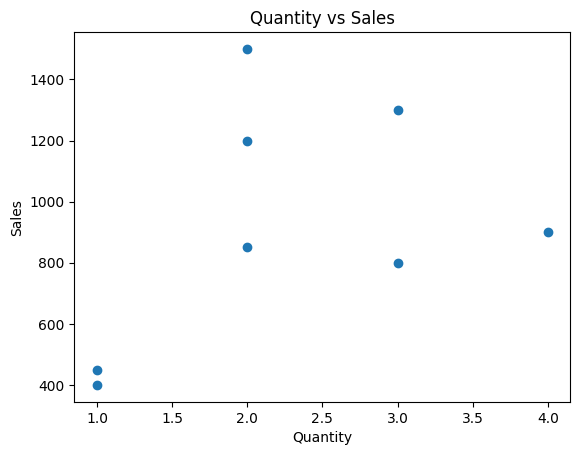

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df["Quantity"], df["Sales"])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

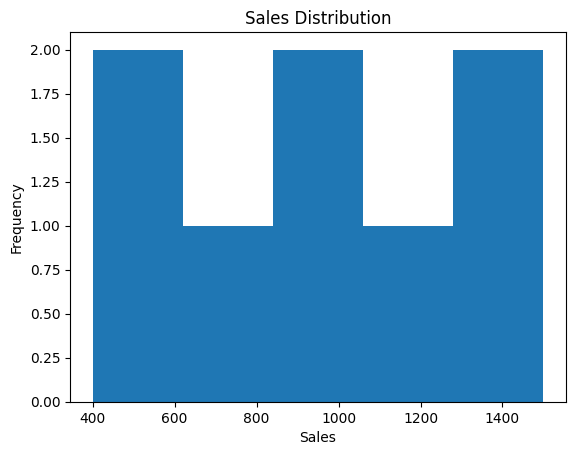

In [3]:
plt.hist(df["Sales"], bins=5)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [4]:
df.isnull().sum()

Product     0
Category    0
Sales       0
Quantity    0
Profit      0
dtype: int64

In [5]:
df.loc[2,"Sales"] = None
df

,Product,Category,Sales,Quantity,Profit
0,Laptop,Electronics,1200.0,2,200
1,Phone,Electronics,800.0,3,150
2,Tablet,Electronics,NaN,1,80
3,Laptop,Electronics,1500.0,2,250
4,Phone,Electronics,900.0,4,160
5,Tablet,Electronics,450.0,1,90
6,Laptop,Electronics,1300.0,3,210
7,Phone,Electronics,850.0,2,140


In [6]:
df["Sales"].fillna(df["Sales"].mean(), inplace=True)
df

/tmp/ipykernel_3095/3982019502.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Sales"].fillna(df["Sales"].mean(), inplace=True)


,Product,Category,Sales,Quantity,Profit
0,Laptop,Electronics,1200.0,2,200
1,Phone,Electronics,800.0,3,150
2,Tablet,Electronics,NaN,1,80
3,Laptop,Electronics,1500.0,2,250
4,Phone,Electronics,900.0,4,160
5,Tablet,Electronics,450.0,1,90
6,Laptop,Electronics,1300.0,3,210
7,Phone,Electronics,850.0,2,140


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Product   8 non-null      str    
 1   Category  8 non-null      str    
 2   Sales     7 non-null      float64
 3   Quantity  8 non-null      int64  
 4   Profit    8 non-null      int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 452.0 bytes


In [8]:
df.describe()

,Sales,Quantity,Profit
count,7.000000,8.000000,8.000000
mean,1000.000000,2.250000,160.000000
std,354.729944,1.035098,58.554004
min,450.000000,1.000000,80.000000
25%,825.000000,1.750000,127.500000
50%,900.000000,2.000000,155.000000
75%,1250.000000,3.000000,202.500000
max,1500.000000,4.000000,250.000000


In [9]:
print("Minimum:", df["Sales"].min())
print("Maximum:", df["Sales"].max())
print("Mean:", df["Sales"].mean())
print("Median:", df["Sales"].median())
print("Mode:", df["Sales"].mode())

Minimum: 450.0
Maximum: 1500.0
Mean: 1000.0
Median: 900.0
Mode: 0     450.0
1     800.0
2     850.0
3     900.0
4    1200.0
5    1300.0
6    1500.0
Name: Sales, dtype: float64


In [10]:
print("Range:", df["Sales"].max() - df["Sales"].min())
print("Variance:", df["Sales"].var())
print("Standard Deviation:", df["Sales"].std())

Range: 1050.0
Variance: 125833.33333333333
Standard Deviation: 354.7299442298794


In [11]:
df.corr(numeric_only=True)

,Sales,Quantity,Profit
Sales,1.000000,0.216650,0.993411
Quantity,0.216650,1.000000,0.447834
Profit,0.993411,0.447834,1.000000


In [12]:
Q1 = data['Sales'].quantile(0.25)
Q3 = data['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
filtered_data = data[(data['Sales'] >= lower) & (data['Sales'] <= upper)]

AttributeError: 'list' object has no attribute 'quantile'

In [13]:
# Calculate Quartiles
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# Define outlier limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

# Detect outliers
outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]

print("Outliers Found:")
print(outliers)

Q1: 825.0
Q3: 1250.0
IQR: 425.0
Lower Limit: 187.5
Upper Limit: 1887.5
Outliers Found:
Empty DataFrame
Columns: [Product, Category, Sales, Quantity, Profit]
Index: []


In [14]:
# Remove outliers
filtered_data = df[(df['Sales'] >= lower) & (df['Sales'] <= upper)]

print("Dataset after removing outliers:")
filtered_data

Dataset after removing outliers:


,Product,Category,Sales,Quantity,Profit
0,Laptop,Electronics,1200.0,2,200
1,Phone,Electronics,800.0,3,150
3,Laptop,Electronics,1500.0,2,250
4,Phone,Electronics,900.0,4,160
5,Tablet,Electronics,450.0,1,90
6,Laptop,Electronics,1300.0,3,210
7,Phone,Electronics,850.0,2,140


In [15]:
print("Original Dataset Size:", df.shape)

Original Dataset Size: (8, 5)


In [16]:
sample_data = df.sample(frac=0.5, random_state=1)

print("Sampled Dataset:")
sample_data

Sampled Dataset:


,Product,Category,Sales,Quantity,Profit
7,Phone,Electronics,850.0,2,140
2,Tablet,Electronics,NaN,1,80
1,Phone,Electronics,800.0,3,150
6,Laptop,Electronics,1300.0,3,210


In [17]:
reduced_data = sample_data.drop(columns=['Category'])

print("Dataset After Column Removal:")
reduced_data

Dataset After Column Removal:


,Product,Sales,Quantity,Profit
7,Phone,850.0,2,140
2,Tablet,NaN,1,80
1,Phone,800.0,3,150
6,Laptop,1300.0,3,210


In [18]:
print("Sales Column Before Scaling:")
df['Sales']

Sales Column Before Scaling:


0    1200.0
1     800.0
2       NaN
3    1500.0
4     900.0
5     450.0
6    1300.0
7     850.0
Name: Sales, dtype: float64

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Sales_scaled'] = scaler.fit_transform(df[['Sales']])

print("Dataset After Scaling:")
df[['Sales', 'Sales_scaled']]

Dataset After Scaling:


,Sales,Sales_scaled
0,1200.0,0.714286
1,800.0,0.333333
2,NaN,NaN
3,1500.0,1.000000
4,900.0,0.428571
5,450.0,0.000000
6,1300.0,0.809524
7,850.0,0.380952
